In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from monai.data import DataLoader
from monai import transforms

# Importar tus clases unificadas
from src.get_data import UnifiedDataset
from src.custom_transforms import (
    ImputeMissingChannelsd,
    RandModalityDropoutd,
    ConvertToMultiChannelPipeline1d,
    ConvertToMultiChannelPipeline2d
)

/home/minigo/anaconda3/envs/monai_env/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


[TRAIN] Cargados 331 casos de UPenn-GBM (Pipeline 1)
[TRAIN] Cargados 273 casos de MU-Glioma Post (Pipeline 1)
¡Paciente PatientID_0003 encontrado en el índice 470!
Forma del tensor de imagen final: torch.Size([11, 134, 172, 143])
Forma del tensor de etiqueta final: torch.Size([2, 134, 172, 143])


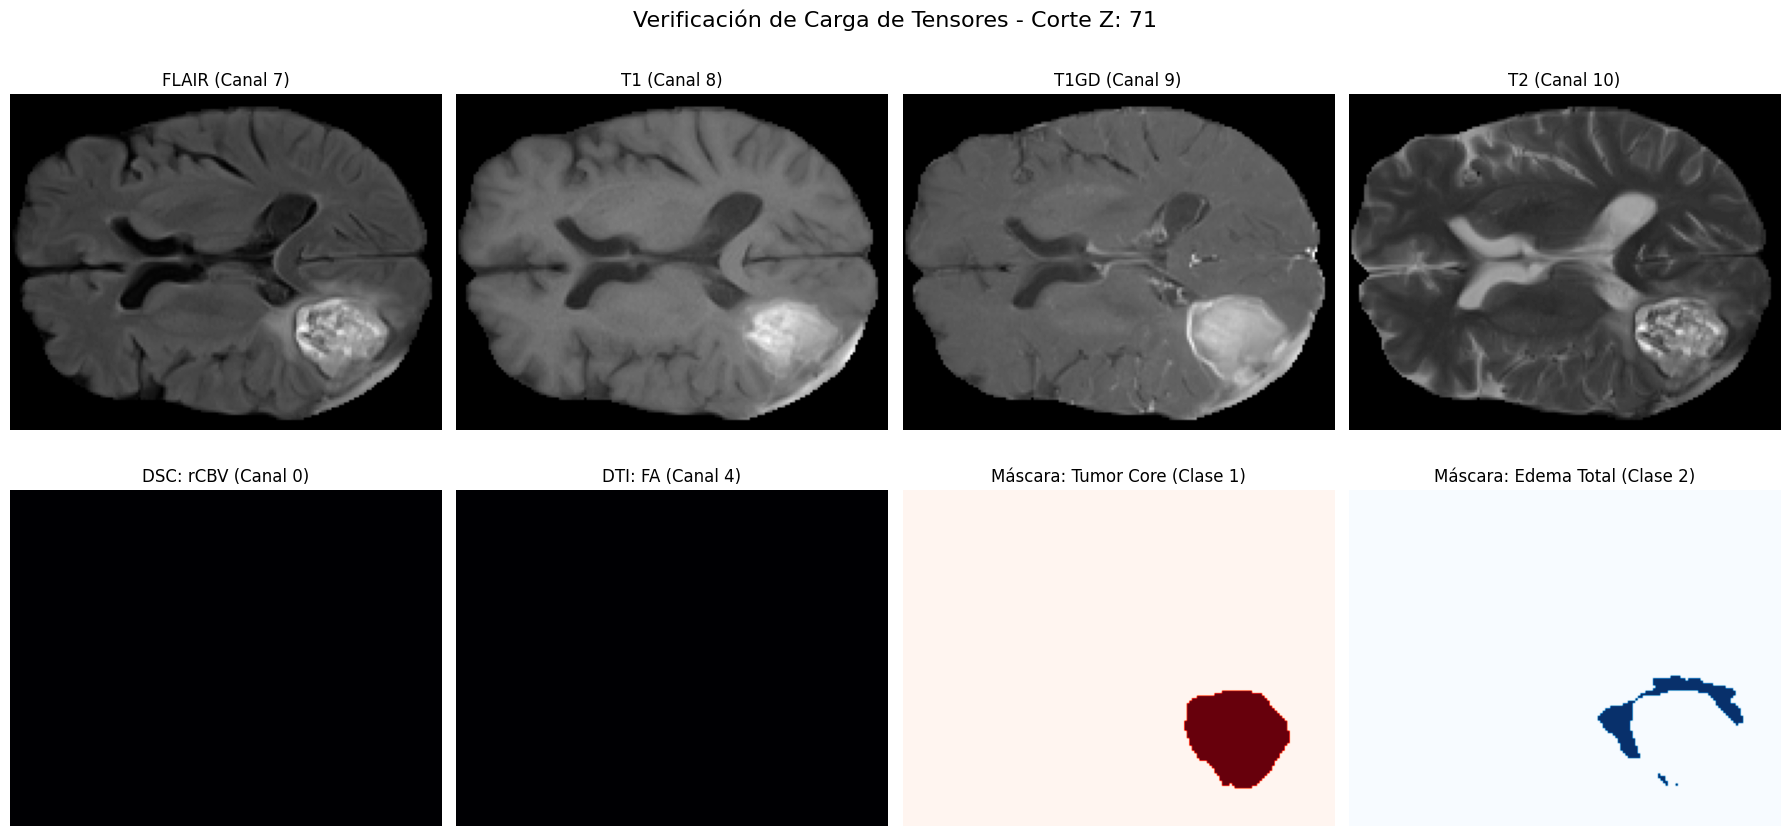

In [2]:

# 1. Definir Rutas (Ajusta estas a tus directorios reales)
UPENN_DIR = "./Dataset/Dataset_331_30_casos/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"
PIPELINE = 1  # 1 para Tumor Core/Edema, 2 para Infiltración/Vasogénico

# 2. Definir las transformaciones de prueba
# Solo usaremos carga, estandarización y recorte para visualizar el tensor crudo
test_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    
    # Unificación de Canales a 11
    ImputeMissingChannelsd(keys=["image"]),
    
    # Dropout (puesto al 0% para ver siempre los datos reales si existen, 
    # cámbialo a 1.0 si quieres probar que se apaguen forzosamente)
    RandModalityDropoutd(keys=["image"], prob=0.0),
    
    # Formateo de Etiquetas (Ajustar a Pipeline 2 si es necesario)
    ConvertToMultiChannelPipeline1d(keys=["label"]),
    
    # Recorte al cerebro para centrar la imagen
    transforms.CropForegroundd(keys=["image", "label"], source_key="image")
])

# 3. Instanciar el Dataset Unificado y el DataLoader
test_set = UnifiedDataset(
    upenn_dir=UPENN_DIR, 
    muglioma_dir=MUGLIOMA_DIR, 
    section="train", 
    pipeline=PIPELINE,
    transform=test_transform
)

# Usamos batch_size=1 para facilitar la extracción
test_loader = DataLoader(test_set, batch_size=1, shuffle=False)

# 4. Extraer un caso aleatorio
# batch_data = next(iter(test_loader))

# imagen = batch_data["image"][0] # Shape: [11, H, W, D]
# etiqueta = batch_data["label"][0] # Shape: [2, H, W, D]
# ---------------------------------------------------------------------

# # Elegir el índice que quieres visualizar (ej. el 5to paciente)
# indice_paciente = 100 

# # Extraer directamente del Dataset (no del loader)
# # Nota: Como no pasa por el DataLoader, no tiene la dimensión del batch [B, C, H, W, D],
# # por lo que no necesitas hacer [0] al final.
# batch_data = test_set[indice_paciente]

# imagen = batch_data["image"] # Shape directo: [11, H, W, D]
# etiqueta = batch_data["label"] # Shape directo: [2, H, W, D]
# print(f"Mostrando el caso en el índice {indice_paciente}")
#-----------------------------------------------------------------------

# 1. Definir el paciente que quieres buscar (ej. de UPenn o MU-Glioma)
id_buscado = "PatientID_0003" # O "UPENN-GBM-00055"
# id_buscado = "UPENN-GBM-00006" 

# 2. Buscar en la lista de diccionarios crudos del dataset
indice_encontrado = None
for i, data_dict in enumerate(test_set.data):
    if id_buscado in data_dict["label"]:
        indice_encontrado = i
        ruta_encontrada = data_dict["label"]
        break

batch_data = test_set[indice_encontrado]

imagen = batch_data["image"] # Shape directo: [11, H, W, D]
etiqueta = batch_data["label"] # Shape directo: [2, H, W, D]
print(f"¡Paciente {id_buscado} encontrado en el índice {indice_encontrado}!")
#-----------------------------------------------------------------------

print(f"Forma del tensor de imagen final: {imagen.shape}")
print(f"Forma del tensor de etiqueta final: {etiqueta.shape}")

# 5. Configurar la Visualización
# Elegimos el corte central en el eje Z (profundidad)
corte_z = imagen.shape[-1] // 2

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(f'Verificación de Carga de Tensores - Corte Z: {corte_z}', fontsize=16)

# Fila 1: Modalidades Estructurales (Índices 7 al 10 en tu diseño)
nombres_estructurales = ['FLAIR (Canal 7)', 'T1 (Canal 8)', 'T1GD (Canal 9)', 'T2 (Canal 10)']
for i, ax in enumerate(axes[0]):
    canal_idx = i + 7
    ax.imshow(imagen[canal_idx, :, :, corte_z].numpy(), cmap="gray")
    ax.set_title(nombres_estructurales[i])
    ax.axis("off")

# Fila 2: Canales Funcionales y Etiquetas
# Mostramos un canal DSC (rCBV) y un canal DTI (FA)
axes[1, 0].imshow(imagen[0, :, :, corte_z].numpy(), cmap="magma")
axes[1, 0].set_title('DSC: rCBV (Canal 0)')
axes[1, 0].axis("off")

axes[1, 1].imshow(imagen[4, :, :, corte_z].numpy(), cmap="magma")
axes[1, 1].set_title('DTI: FA (Canal 4)')
axes[1, 1].axis("off")

# Mostramos las Etiquetas según el Pipeline 1
axes[1, 2].imshow(etiqueta[0, :, :, corte_z].numpy(), cmap="Reds")
axes[1, 2].set_title('Máscara: Tumor Core (Clase 1)')
axes[1, 2].axis("off")

axes[1, 3].imshow(etiqueta[1, :, :, corte_z].numpy(), cmap="Blues")
axes[1, 3].set_title('Máscara: Edema Total (Clase 2)')
axes[1, 3].axis("off")

plt.tight_layout()
plt.show()

Inicializando dataset...
[TRAIN] Cargados 30 casos de UPenn-GBM (Pipeline 2)
[TRAIN] Cargados 190 casos de MU-Glioma Post (Pipeline 2)

¡Éxito! Paciente 'PatientID_0003' encontrado en el índice [129].
Cargando ground truth desde: ./Dataset/MU_glioma/train/PatientID_0003/Timepoint_1/PatientID_0003_Timepoint_1_tumorMask_2.nii.gz


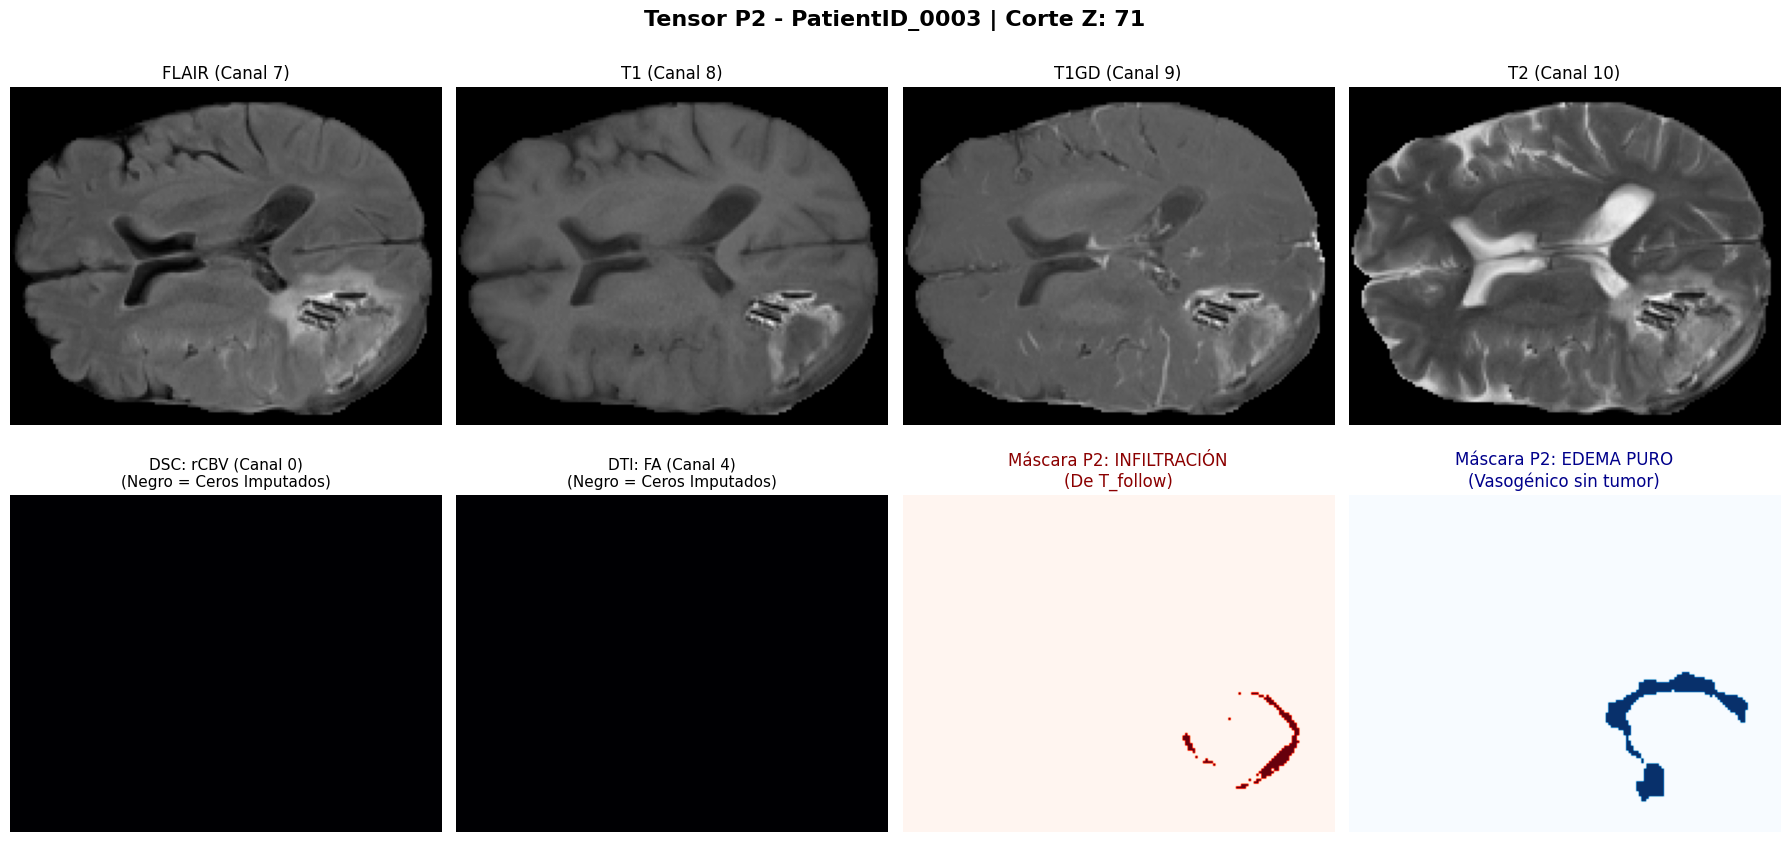

In [3]:
# 1. Definir Rutas (Ajusta estas a tus directorios reales)
UPENN_DIR = "./Dataset/Dataset_30_6/"
MUGLIOMA_DIR = "./Dataset/MU_glioma/"
PIPELINE = 2  # Cambiado al Pipeline 2 (Infiltración vs Edema Puro)

# Definir el paciente exacto que queremos buscar
# Puedes cambiar esto por "UPENN-GBM-00055" para probar un caso con 11 modalidades
ID_BUSCADO = "PatientID_0003" 

# 2. Definir las transformaciones de prueba para P2
test_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "label"]),
    transforms.EnsureChannelFirstd(keys=["image", "label"]),
    
    # Unificación de Canales a 11
    ImputeMissingChannelsd(keys=["image"]),
    
    # Dropout (0.0 para no forzar ceros en UPenn y ver si cargan bien)
    RandModalityDropoutd(keys=["image"], prob=0.0),
    
    # Formateo de Etiquetas PARA PIPELINE 2
    ConvertToMultiChannelPipeline2d(keys=["label"]),
    
    # Recorte al cerebro para centrar la visualización
    transforms.CropForegroundd(keys=["image", "label"], source_key="image")
])

# 3. Instanciar el Dataset Unificado
# Nota: La carga inicial listará los archivos, pero no aplicará transformaciones hasta hacer el llamado [indice]
print("Inicializando dataset...")
test_set = UnifiedDataset(
    upenn_dir=UPENN_DIR, 
    muglioma_dir=MUGLIOMA_DIR, 
    section="train", 
    pipeline=PIPELINE,
    transform=test_transform
)

# 4. Opción 3: Buscar el índice del paciente deseado
indice_encontrado = None
ruta_encontrada = ""

for i, data_dict in enumerate(test_set.data):
    if ID_BUSCADO in data_dict["label"]:
        indice_encontrado = i
        ruta_encontrada = data_dict["label"]
        break

# 5. Visualización si se encuentra el paciente
if indice_encontrado is not None:
    print(f"\n¡Éxito! Paciente '{ID_BUSCADO}' encontrado en el índice [{indice_encontrado}].")
    print(f"Cargando ground truth desde: {ruta_encontrada}")
    
    # Extraer el caso (AQUÍ se ejecutan las transformaciones on-the-fly)
    caso_especifico = test_set[indice_encontrado]
    imagen = caso_especifico["image"]   # Shape esperado: [11, H, W, D]
    etiqueta = caso_especifico["label"] # Shape esperado: [2, H, W, D]
    
    # Configurar el corte Z central para la visualización
    corte_z = imagen.shape[-1] // 2

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle(f'Tensor P2 - {ID_BUSCADO} | Corte Z: {corte_z}', fontsize=16, fontweight='bold')

    # Fila 1: Modalidades Estructurales (Índices 7 al 10)
    nombres_estructurales = ['FLAIR (Canal 7)', 'T1 (Canal 8)', 'T1GD (Canal 9)', 'T2 (Canal 10)']
    for i, ax in enumerate(axes[0]):
        canal_idx = i + 7
        ax.imshow(imagen[canal_idx, :, :, corte_z].numpy(), cmap="gray")
        ax.set_title(nombres_estructurales[i], fontsize=12)
        ax.axis("off")

    # Fila 2: Control de Imputación y Máscaras Pipeline 2
    # Canal de Perfusión (Debería verse negro si es MU-Glioma)
    axes[1, 0].imshow(imagen[0, :, :, corte_z].numpy(), cmap="magma")
    axes[1, 0].set_title('DSC: rCBV (Canal 0)\n(Negro = Ceros Imputados)', fontsize=11)
    axes[1, 0].axis("off")

    # Canal de Difusión (Debería verse negro si es MU-Glioma)
    axes[1, 1].imshow(imagen[4, :, :, corte_z].numpy(), cmap="magma")
    axes[1, 1].set_title('DTI: FA (Canal 4)\n(Negro = Ceros Imputados)', fontsize=11)
    axes[1, 1].axis("off")

    # Máscaras del PIPELINE 2
    axes[1, 2].imshow(etiqueta[0, :, :, corte_z].numpy(), cmap="Reds")
    axes[1, 2].set_title('Máscara P2: INFILTRACIÓN\n(De T_follow)', fontsize=12, color='darkred')
    axes[1, 2].axis("off")

    axes[1, 3].imshow(etiqueta[1, :, :, corte_z].numpy(), cmap="Blues")
    axes[1, 3].set_title('Máscara P2: EDEMA PURO\n(Vasogénico sin tumor)', fontsize=12, color='darkblue')
    axes[1, 3].axis("off")

    plt.tight_layout()
    plt.show()

else:
    print(f"\n❌ Error: El paciente '{ID_BUSCADO}' no se encuentra en el dataset cargado.")
    print("Verifica si el ID está bien escrito o si la carpeta de ese paciente tiene el sufijo correcto.")